In [1]:
from google.colab import drive
drive.mount('/content/drive')

!pip install -q transformers pandas scikit-learn scipy tqdm matplotlib accelerate

import os, json, random
import numpy as np
import pandas as pd
from tqdm import tqdm
from collections import defaultdict

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW

from transformers import AutoTokenizer, AutoModel, get_cosine_schedule_with_warmup
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.stats import pearsonr
import matplotlib.pyplot as plt

Mounted at /content/drive


In [2]:
# ================= CONFIG =================

MODEL_NAME = "microsoft/mpnet-base"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

MAX_LEN = 512
BATCH = 2
ACCUM = 8

EPOCHS = 12
LR = 1e-5
WEIGHT_DECAY = 0.01
PATIENCE = 3

MULTIPLIER = 6

TRAITS = [
"openness",
"conscientiousness",
"extraversion",
"agreeableness",
"neuroticism"
]

DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Project_One/pandora_user_level_paper_108.parquet"

SAVE_DIR = "/content/drive/MyDrive/Colab Notebooks/Project_One/mpnet_personality_model"

os.makedirs(SAVE_DIR, exist_ok=True)


In [3]:
# ================= LOAD DATA =================

df = pd.read_parquet(DATA_PATH)

df = df.dropna(subset=TRAITS).reset_index(drop=True)

df["uid"] = df.index

print("Users:",len(df))

trait_means = df[TRAITS].mean()
trait_stds = df[TRAITS].std()+1e-6

df[TRAITS] = (df[TRAITS]-trait_means)/trait_stds

train_df,val_df = train_test_split(df,test_size=0.2,random_state=42)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

Users: 1484


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/493 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

In [4]:
# ================= DATASET =================

class PandoraDataset(Dataset):

    def __init__(self,df):

        self.text = df.text.tolist()
        self.y = df[TRAITS].values.astype(np.float32)
        self.uid = df.uid.tolist()

    def __len__(self):

        return len(self.text)*MULTIPLIER

    def __getitem__(self,i):

        i %= len(self.text)

        t = self.text[i]

        words = t.split()

        if len(words) > 800:

            s = random.randint(0,len(words)-800)

            t = " ".join(words[s:s+800])

        enc = tokenizer(
            t,
            truncation=True,
            max_length=MAX_LEN,
            padding="max_length",
            return_tensors="pt"
        )

        y = torch.tensor(self.y[i])*0.9

        return (
            enc["input_ids"].squeeze(),
            enc["attention_mask"].squeeze(),
            y,
            torch.tensor(self.uid[i])
        )

train_loader = DataLoader(PandoraDataset(train_df),batch_size=BATCH,shuffle=True)
val_loader = DataLoader(PandoraDataset(val_df),batch_size=BATCH)


In [5]:
# ================= MODEL =================

class MPNetRegressor(nn.Module):

    def __init__(self):

        super().__init__()

        self.encoder = AutoModel.from_pretrained(MODEL_NAME)

        h = self.encoder.config.hidden_size

        self.attention = nn.Linear(h,1)

        self.projection = nn.Sequential(
            nn.Linear(h,256),
            nn.GELU(),
            nn.Dropout(0.3)
        )

        self.heads = nn.ModuleList(
            [nn.Linear(256,1) for _ in range(5)]
        )

    def forward(self,input_ids,mask):

        x = self.encoder(
            input_ids,
            attention_mask=mask
        ).last_hidden_state

        w = torch.softmax(self.attention(x),1)

        x = (x*w).sum(1)

        x = self.projection(x)

        out = torch.cat([h(x) for h in self.heads],1)

        return out

model = MPNetRegressor().to(DEVICE)

# freeze encoder initially

for p in model.encoder.parameters():
    p.requires_grad = False


model.safetensors:   0%|          | 0.00/532M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: microsoft/mpnet-base
Key                       | Status     | 
--------------------------+------------+-
lm_head.dense.weight      | UNEXPECTED | 
lm_head.decoder.weight    | UNEXPECTED | 
lm_head.bias              | UNEXPECTED | 
lm_head.layer_norm.bias   | UNEXPECTED | 
lm_head.decoder.bias      | UNEXPECTED | 
lm_head.dense.bias        | UNEXPECTED | 
lm_head.layer_norm.weight | UNEXPECTED | 
pooler.dense.bias         | MISSING    | 
pooler.dense.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [6]:
# ================= OPTIM =================

loss_fn = nn.SmoothL1Loss()

optimizer = AdamW(
model.parameters(),
lr=LR,
weight_decay=WEIGHT_DECAY
)

steps = (len(train_loader)*EPOCHS)//ACCUM

scheduler = get_cosine_schedule_with_warmup(
optimizer,
0,
steps
)

scaler = torch.cuda.amp.GradScaler()

/tmp/ipykernel_1430/433404987.py:19: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler()


In [7]:
# ================= TRAIN =================

best = 1e9
bad = 0

train_hist=[]
val_hist=[]

for ep in range(EPOCHS):

    if ep==3:

        for p in model.encoder.encoder.layer[-2:].parameters():
            p.requires_grad=True

    if ep==6:

        for p in model.encoder.parameters():
            p.requires_grad=True

    model.train()

    optimizer.zero_grad()

    losses=[]

    for step,(i,m,y,_) in enumerate(tqdm(train_loader)):

        i=i.to(DEVICE)
        m=m.to(DEVICE)
        y=y.to(DEVICE)

        with torch.cuda.amp.autocast():

            loss = loss_fn(model(i,m),y)/ACCUM

        scaler.scale(loss).backward()

        if (step+1)%ACCUM==0:

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                model.parameters(),
                1
            )

            scaler.step(optimizer)
            scaler.update()

            scheduler.step()

            optimizer.zero_grad()

        losses.append(loss.item()*ACCUM)

    train_loss=np.mean(losses)

    model.eval()

    vloss=[]

    with torch.no_grad():

        for i,m,y,_ in val_loader:

            pred=model(
                i.to(DEVICE),
                m.to(DEVICE)
            )

            vloss.append(
                loss_fn(pred,y.to(DEVICE)).item()
            )

    val_loss=np.mean(vloss)

    train_hist.append(train_loss)
    val_hist.append(val_loss)

    print(f"Epoch {ep+1} | Train {train_loss:.3f} | Val {val_loss:.3f}")

    if val_loss < best:

        best = val_loss
        bad = 0

        torch.save(
            model.state_dict(),
            f"{SAVE_DIR}/model.pt"
        )

    else:

        bad += 1

        if bad >= PATIENCE:
            print("Early stopping")
            break

  0%|          | 0/3561 [00:00<?, ?it/s]/tmp/ipykernel_1430/3722968937.py:33: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
100%|██████████| 3561/3561 [03:02<00:00, 19.56it/s]


Epoch 1 | Train 0.383 | Val 0.382


100%|██████████| 3561/3561 [02:55<00:00, 20.34it/s]


Epoch 2 | Train 0.381 | Val 0.382


100%|██████████| 3561/3561 [02:55<00:00, 20.29it/s]


...

Epoch 10 | Train 0.332 | Val 0.373


100%|██████████| 3561/3561 [06:53<00:00,  8.61it/s]


Epoch 11 | Train 0.329 | Val 0.369


100%|██████████| 3561/3561 [06:55<00:00,  8.56it/s]


Epoch 12 | Train 0.327 | Val 0.372
Early stopping


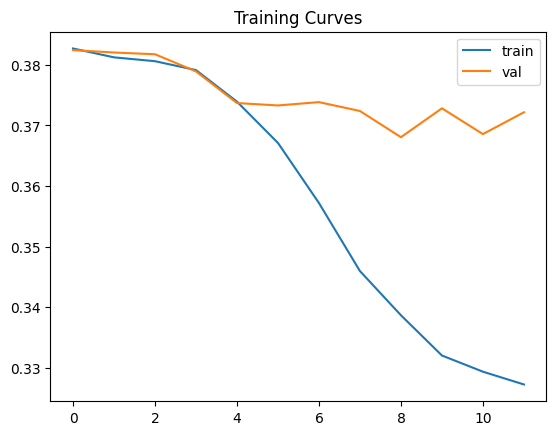

In [8]:
# ================= CURVES =================

plt.plot(train_hist)
plt.plot(val_hist)
plt.legend(["train","val"])
plt.title("Training Curves")
plt.show()

In [9]:
# ================= METRICS =================

model.load_state_dict(torch.load(f"{SAVE_DIR}/model.pt"))
model.eval()

P = defaultdict(list)
T = {}

with torch.no_grad():

    for i,m,y,u in val_loader:

        out = model(
            i.to(DEVICE),
            m.to(DEVICE)
        ).cpu()

        for k,uid in enumerate(u):

            P[uid.item()].append(out[k])
            T[uid.item()] = y[k]

X=[]
Y=[]

for u in P:

    X.append(torch.stack(P[u]).mean(0))
    Y.append(T[u])

X=torch.stack(X).numpy()*trait_stds.values+trait_means.values
Y=torch.stack(Y).numpy()*trait_stds.values+trait_means.values

print("\n=== FINAL MPNet METRICS ===")

for i,t in enumerate(TRAITS):

    mae=mean_absolute_error(Y[:,i],X[:,i])
    mse=mean_squared_error(Y[:,i],X[:,i])
    rmse=np.sqrt(mse)
    r=pearsonr(Y[:,i],X[:,i])[0]

    print(t,"MAE",mae,"MSE",mse,"RMSE",rmse,"R",r)

print("\nMacro MAE:",mean_absolute_error(Y,X))
print("Macro RMSE:",np.sqrt(mean_squared_error(Y,X)))
print("R2:",r2_score(Y,X))




=== FINAL MPNet METRICS ===
openness MAE 20.5976208935625 MSE 592.0938056731325 RMSE 24.332977739543768 R 0.22735894175418375
conscientiousness MAE 22.581815366729263 MSE 706.8133777018955 RMSE 26.58596204206076 R 0.28558978764337
extraversion MAE 22.919648603063862 MSE 784.1344761638628 RMSE 28.002401257104054 R 0.2322092359657673
agreeableness MAE 23.093635811335904 MSE 700.5663231690752 RMSE 26.46821344875916 R 0.28400618519514687
neuroticism MAE 24.52749609389466 MSE 819.9994867512252 RMSE 28.635633164838964 R 0.3201961343541359

Macro MAE: 22.744043353717245
Macro RMSE: 26.846256608544856
R2: 0.03366602530607203


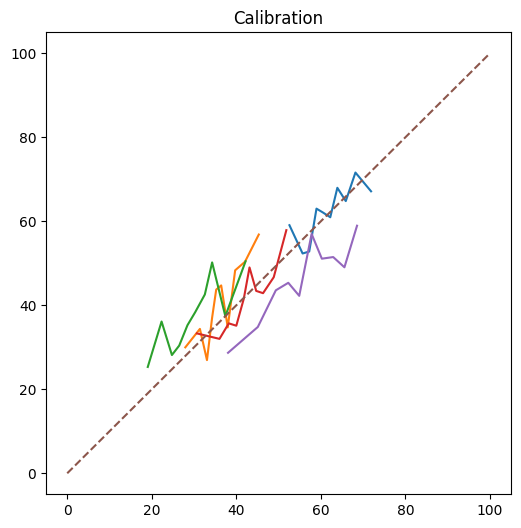

In [10]:
# ================= CALIBRATION =================

def calib(a,b):
    idx=np.argsort(b);a=a[idx];b=b[idx]
    s=len(a)//10
    return [b[i*s:(i+1)*s].mean() for i in range(10)], [a[i*s:(i+1)*s].mean() for i in range(10)]

plt.figure(figsize=(6,6))
for i in range(5):
    xs,ys=calib(Y[:,i],X[:,i])
    plt.plot(xs,ys)

plt.plot([0,100],[0,100],'--')
plt.title("Calibration")
plt.show()

In [11]:
# ================= SAVE BUNDLE =================

tokenizer.save_pretrained(SAVE_DIR)

with open(f"{SAVE_DIR}/norm.json","w") as f:
    json.dump({t:{"mean":float(trait_means[t]),"std":float(trait_stds[t])} for t in TRAITS},f,indent=2)

print("✅ Full model saved:",SAVE_DIR)

✅ Full model saved: /content/drive/MyDrive/Colab Notebooks/Project_One/mpnet_personality_model
